#0. Setup & Imports




In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

plt.rcParams['figure.figsize'] = (12, 4)

print('Libraries imported.')

Libraries imported.


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# 1. Load the Raw Data


In [27]:
import pandas as pd

# 1️⃣ Set path to your dataset
data_path = '/content/drive/MyDrive/RAW_House10_Part1.csv'

# 2️⃣ Load CSV with proper options
df = pd.read_csv(
    data_path,
    sep=',',          # CSV separator
    header=0,         # first row has column names
    low_memory=False  # avoids mixed-type warnings for large files
)

# 3️⃣ Inspect the data
print("Raw data loaded:")
print(df.head())
print(df.info())

# 4️⃣ Check numeric columns (aggregate + appliances)
numeric_cols = ['Aggregate','Appliance1','Appliance2','Appliance3','Appliance4',
                'Appliance5','Appliance6','Appliance7','Appliance8','Appliance9']

print("\nNumeric columns sample:")
print(df[numeric_cols].head())


Raw data loaded:
                  Time        Unix  Aggregate  Appliance1  Appliance2  \
0  2013-11-20 11:31:18  1384947077       3078           0          70   
1  2013-11-20 11:31:31  1384947090       3078           0          70   
2  2013-11-20 11:31:45  1384947105        215           0          69   
3  2013-11-20 11:31:58  1384947118        212           0          71   
4  2013-11-20 11:32:18  1384947138        213           0          70   

   Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  \
0           0           0           0           2          25           0   
1           0           0           0           1          25           0   
2           0           0           0           1          25           0   
3           0           0           0           2          25           0   
4           0           0           0           2          25           0   

   Appliance9  
0           0  
1           0  
2           0  
3           0  
4



#2. Convert Time Information



In [28]:
# Convert UNIX timestamp to datetime
df['datetime'] = pd.to_datetime(df['Unix'], unit='s')

# Set as index and sort
df = df.set_index('datetime')
df = df.sort_index()

print('After datetime conversion:')
print(df.head())


After datetime conversion:
                                    Time        Unix  Aggregate  Appliance1  \
datetime                                                                      
2013-11-20 11:31:17  2013-11-20 11:31:18  1384947077       3078           0   
2013-11-20 11:31:30  2013-11-20 11:31:31  1384947090       3078           0   
2013-11-20 11:31:45  2013-11-20 11:31:45  1384947105        215           0   
2013-11-20 11:31:58  2013-11-20 11:31:58  1384947118        212           0   
2013-11-20 11:32:18  2013-11-20 11:32:18  1384947138        213           0   

                     Appliance2  Appliance3  Appliance4  Appliance5  \
datetime                                                              
2013-11-20 11:31:17          70           0           0           0   
2013-11-20 11:31:30          70           0           0           0   
2013-11-20 11:31:45          69           0           0           0   
2013-11-20 11:31:58          71           0           0         

#3. Remove Duplicates and Corrupted Values



In [29]:
# Count before
before = len(df)

# Keep only the first entry for each timestamp
df = df[~df.index.duplicated(keep='first')]

# Count after
after = len(df)
print(f"Removed {before - after} duplicate rows.")
# Get IAM columns
iam_cols = [col for col in df.columns if 'Appliance' in col]

# Replace values > 4000 W with 0
df[iam_cols] = df[iam_cols].where(df[iam_cols] <= 4000, 0)

print("IAM outliers corrected:")
print(df[iam_cols].describe())

# Forward fill small gaps (<2 minutes, 8s*15≈2min), then fill longer gaps with 0
df = df.ffill(limit=15)
df = df.fillna(0)

print("Missing values handled:")
print(df.isna().sum())


Removed 441933 duplicate rows.
IAM outliers corrected:
         Appliance1    Appliance2    Appliance3    Appliance4    Appliance5  \
count  3.512453e+06  3.512453e+06  3.512453e+06  3.512453e+06  3.512453e+06   
mean   2.518971e+01  2.866023e+01  4.234088e+01  2.157734e+01  3.445383e+01   
std    3.717281e+01  4.155901e+01  3.933021e+01  4.319224e+01  2.244878e+02   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%    0.000000e+00  0.000000e+00  6.700000e+01  0.000000e+00  0.000000e+00   
75%    7.300000e+01  7.000000e+01  7.300000e+01  0.000000e+00  0.000000e+00   
max    3.584000e+03  2.632000e+03  2.116000e+03  2.159000e+03  2.720000e+03   

         Appliance6    Appliance7    Appliance8    Appliance9  
count  3.512453e+06  3.512453e+06  3.512453e+06  3.512453e+06  
mean   2.522993e+02  5.876929e+01  3.429396e+00  4.281039e+00  
std    6.032204e+02  3.051637e+01  6.2167

# 4. Handle Missing Data


In [30]:
# Liste des colonnes de puissance
power_cols = ['Aggregate'] + [f'Appliance{i}' for i in range(1, 10)]

# Forward fill pour petits écarts (limit=15 échantillons ~ 2 minutes)
df[power_cols] = df[power_cols].ffill(limit=15)

# Remplir les NaN restants par 0
df[power_cols] = df[power_cols].fillna(0)

print("After handling missing data:")
print(df[power_cols].isna().sum())  # Vérifier qu'il n'y a plus de NaN


After handling missing data:
Aggregate     0
Appliance1    0
Appliance2    0
Appliance3    0
Appliance4    0
Appliance5    0
Appliance6    0
Appliance7    0
Appliance8    0
Appliance9    0
dtype: int64


#5. Resample to a Common Time Resolution

In [31]:
# Resample to 1-minute intervals (you can change '1T' to '5T' or '1H')
freq = '1T'

# Resample numeric columns
numeric_cols = ['Aggregate'] + iam_cols
df_resampled = df[numeric_cols].resample(freq).mean()

# Handle any NaN created by resampling
df_resampled = df_resampled.ffill().fillna(0)

print("After resampling:")
print(df_resampled.head())


/tmp/ipython-input-2601899020.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = df[numeric_cols].resample(freq).mean()


After resampling:
                     Aggregate  Appliance1  Appliance2  Appliance3  \
datetime                                                             
2013-11-20 11:31:00   1645.750         0.0       70.00         0.0   
2013-11-20 11:32:00    213.500         0.0       69.25         0.0   
2013-11-20 11:33:00    212.375         0.0       69.50         0.0   
2013-11-20 11:34:00    214.500         0.0       68.80         0.0   
2013-11-20 11:35:00    223.600         0.0       68.90         0.0   

                     Appliance4  Appliance5  Appliance6  Appliance7  \
datetime                                                              
2013-11-20 11:31:00         0.0         0.0        1.50      25.000   
2013-11-20 11:32:00         0.0         0.0        1.25      25.000   
2013-11-20 11:33:00         0.0         0.0        1.50      25.125   
2013-11-20 11:34:00         0.0         0.0        1.30      25.100   
2013-11-20 11:35:00         0.0         0.0        1.20      24.9

#6. (Noise Reduction)

Smoothed series head:
                       Aggregate  Appliance1  Appliance2  Appliance3  \
datetime                                                               
2013-11-20 11:31:00  1645.750000         0.0   70.000000         0.0   
2013-11-20 11:32:00   929.625000         0.0   69.625000         0.0   
2013-11-20 11:33:00   690.541667         0.0   69.583333         0.0   
2013-11-20 11:34:00   571.531250         0.0   69.387500         0.0   
2013-11-20 11:35:00   501.945000         0.0   69.290000         0.0   

                     Appliance4  Appliance5  Appliance6  Appliance7  \
datetime                                                              
2013-11-20 11:31:00         0.0         0.0    1.500000   25.000000   
2013-11-20 11:32:00         0.0         0.0    1.375000   25.000000   
2013-11-20 11:33:00         0.0         0.0    1.416667   25.041667   
2013-11-20 11:34:00         0.0         0.0    1.387500   25.056250   
2013-11-20 11:35:00         0.0         0.0    

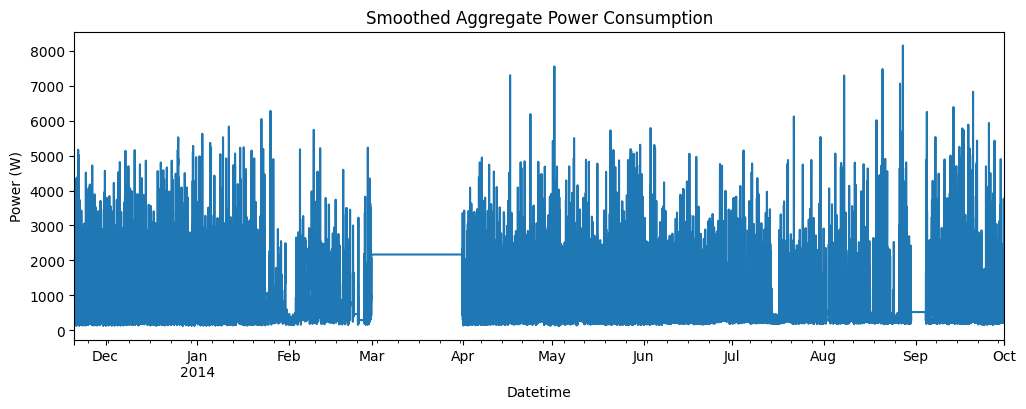

In [32]:
import matplotlib.pyplot as plt

# TODO: ajuster la fenêtre selon la fréquence de resampling
window_size = 5  # ici 5 minutes

# Appliquer le rolling mean
df_smooth = df_resampled.rolling(window=window_size, min_periods=1).mean()

# Afficher un aperçu
print("Smoothed series head:")
print(df_smooth.head())

# Visualiser
plt.figure(figsize=(12, 4))
df_smooth['Aggregate'].plot(title='Smoothed Aggregate Power Consumption')
plt.xlabel('Datetime')
plt.ylabel('Power (W)')
plt.show()


## 7.Normalization

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Initialiser le scaler
scaler = MinMaxScaler()

# Appliquer uniquement sur les colonnes numériques
scaled_data = scaler.fit_transform(df_smooth)

# Recréer un DataFrame avec les mêmes colonnes et index
df_scaled = pd.DataFrame(scaled_data, columns=df_smooth.columns, index=df_smooth.index)

# Aperçu
print("Scaled data sample:")
print(df_scaled.head())


Scaled data sample:
                     Aggregate  Appliance1  Appliance2  Appliance3  \
datetime                                                             
2013-11-20 11:31:00   0.188338         0.0    0.033066         0.0   
2013-11-20 11:32:00   0.098978         0.0    0.032889         0.0   
2013-11-20 11:33:00   0.069144         0.0    0.032869         0.0   
2013-11-20 11:34:00   0.054294         0.0    0.032776         0.0   
2013-11-20 11:35:00   0.045610         0.0    0.032730         0.0   

                     Appliance4  Appliance5  Appliance6  Appliance7  \
datetime                                                              
2013-11-20 11:31:00         0.0         0.0    0.000775    0.059339   
2013-11-20 11:32:00         0.0         0.0    0.000711    0.059339   
2013-11-20 11:33:00         0.0         0.0    0.000732    0.059511   
2013-11-20 11:34:00         0.0         0.0    0.000717    0.059571   
2013-11-20 11:35:00         0.0         0.0    0.000698    0.05

#8 .Segment into Daily Windows (for anomaly detection)

In [34]:
# Resample par jour pour créer des segments quotidiens
daily_segments = [group for _, group in df_scaled.resample('D')]

# Vérifier le premier segment
print("Sample daily segment:")
print(daily_segments[0].head())


Sample daily segment:
                     Aggregate  Appliance1  Appliance2  Appliance3  \
datetime                                                             
2013-11-20 11:31:00   0.188338         0.0    0.033066         0.0   
2013-11-20 11:32:00   0.098978         0.0    0.032889         0.0   
2013-11-20 11:33:00   0.069144         0.0    0.032869         0.0   
2013-11-20 11:34:00   0.054294         0.0    0.032776         0.0   
2013-11-20 11:35:00   0.045610         0.0    0.032730         0.0   

                     Appliance4  Appliance5  Appliance6  Appliance7  \
datetime                                                              
2013-11-20 11:31:00         0.0         0.0    0.000775    0.059339   
2013-11-20 11:32:00         0.0         0.0    0.000711    0.059339   
2013-11-20 11:33:00         0.0         0.0    0.000732    0.059511   
2013-11-20 11:34:00         0.0         0.0    0.000717    0.059571   
2013-11-20 11:35:00         0.0         0.0    0.000698    0.

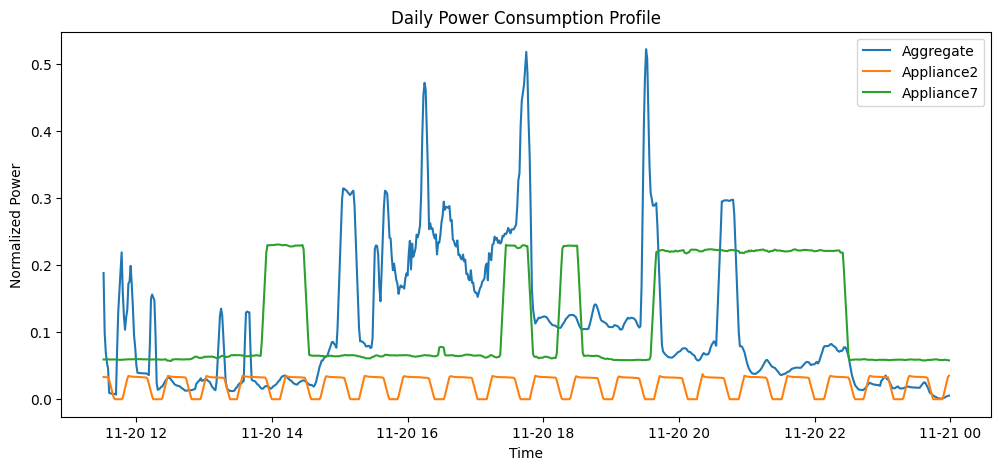

In [35]:
import matplotlib.pyplot as plt

# Choisir le premier jour
daily_segment = daily_segments[0]

# Plot de l'Aggregate et quelques appareils
plt.figure(figsize=(12,5))
plt.plot(daily_segment.index, daily_segment['Aggregate'], label='Aggregate')
plt.plot(daily_segment.index, daily_segment['Appliance2'], label='Appliance2')
plt.plot(daily_segment.index, daily_segment['Appliance7'], label='Appliance7')
plt.xlabel('Time')
plt.ylabel('Normalized Power')
plt.title('Daily Power Consumption Profile')
plt.legend()
plt.show()


# 9. Sanity Checks & Visualization

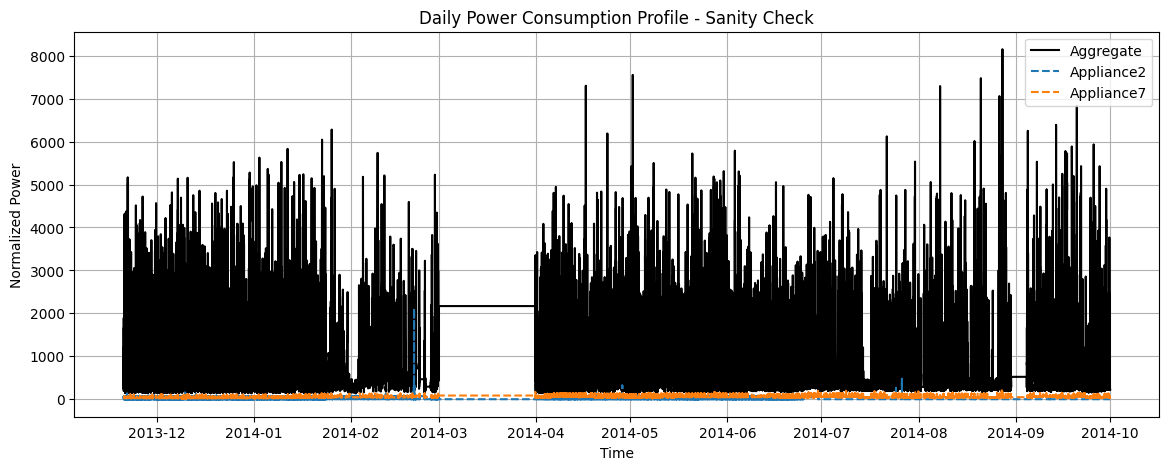

Min/Max values for the day:
                   min          max
Aggregate   136.428283  8150.325000
Appliance1    0.000000   165.542857
Appliance2    0.000000  2117.000000
Appliance3    0.000000   228.753333
Appliance4    0.000000   544.340000
Appliance5    0.000000  2169.988889
Appliance6    0.000000  1935.085714
Appliance7   10.640000   252.640000
Appliance8    0.000000  1174.791111
Appliance9    0.000000  1893.064286

Columns with constant values throughout the day: []

Missing values per column: Aggregate     0
Appliance1    0
Appliance2    0
Appliance3    0
Appliance4    0
Appliance5    0
Appliance6    0
Appliance7    0
Appliance8    0
Appliance9    0
dtype: int64


In [36]:
import matplotlib.pyplot as plt

# Supposons que "daily_segments" est une liste de DataFrames, un par jour
# Si tu n'as qu'un seul DataFrame complet, tu peux créer un segment quotidien comme ceci :
daily_segments = [df_smooth]  # ici df_smooth est ton DataFrame resamplé, lissé et normalisé

# Choisir le premier jour à visualiser
daily_segment = daily_segments[0]

# Plot de l'Aggregate et de quelques appareils représentatifs
plt.figure(figsize=(14,5))
plt.plot(daily_segment.index, daily_segment['Aggregate'], label='Aggregate', color='black')
plt.plot(daily_segment.index, daily_segment['Appliance2'], label='Appliance2', linestyle='--')
plt.plot(daily_segment.index, daily_segment['Appliance7'], label='Appliance7', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Normalized Power')
plt.title('Daily Power Consumption Profile - Sanity Check')
plt.legend()
plt.grid(True)
plt.show()

# Vérification rapide
print("Min/Max values for the day:")
print(daily_segment.describe().T[['min','max']])

# Vérifier s'il y a des valeurs constantes ou des gaps
constant_cols = daily_segment.columns[(daily_segment.max() - daily_segment.min()) == 0].tolist()
print("\nColumns with constant values throughout the day:", constant_cols)

missing_values = daily_segment.isna().sum()
print("\nMissing values per column:", missing_values)
